# Latent Semantic Analysis of New York Times Articles Using PCA

## Objective
This project applies Principal Component Analysis (PCA) for latent semantic analysis of New York Times articles. The goal is to explore whether the principal components can distinguish between articles about art and music, and then use logistic regression to classify the articles.

In [141]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [142]:
#Load the training and test data
train = pd.read_csv("nyt.train.csv")
test = pd.read_csv("nyt.test.csv")

In [143]:
train.shape, test.shape

((80, 4432), (22, 4432))

In [144]:
train.head()

,class.labels,X.,X.d,X.nd,X.s,X.th,X.this,a,abandoned,abc,...,yorkers,yorks,you,young,younger,your,youre,youth,youthful,yu
0,art,0.008707,0.0,0.0,0.000000,0.009251,0.0,0.007564,0.0,0.0,...,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,art,0.005848,0.0,0.0,0.000000,0.000000,0.0,0.001418,0.0,0.0,...,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,art,0.016036,0.0,0.0,0.011403,0.000000,0.0,0.010063,0.0,0.0,...,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,art,0.026415,0.0,0.0,0.000000,0.000000,0.0,0.008677,0.0,0.0,...,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,art,0.007285,0.0,0.0,0.011008,0.000000,0.0,0.008390,0.0,0.0,...,0,0.0,0.048151,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Separate Features and Class Labels

The `class.labels` column contains the article category (art or music), while the remaining columns contain the word features used for latent semantic analysis.

In [145]:
# Separate features and class labels

X_train = train.drop(columns="class.labels")
y_train = train["class.labels"]

X_test = test.drop(columns="class.labels")
y_test = test["class.labels"]

In [146]:
X_train.shape, y_train.shape

((80, 4431), (80,))

In [147]:
# Check class distribution in the training data

y_train.value_counts()

art      45
music    35
Name: class.labels, dtype: int64

## Principal Component Analysis (PCA)

PCA is applied to the training word features to obtain a lower-dimensional representation of the articles. In the context of text data, this approach is used for latent semantic analysis (LSA).

In [148]:
# Perform PCA on the training data

pca = PCA()
X_train_pca = pca.fit_transform(X_train)

In [149]:
X_train_pca.shape

(80, 80)

In [150]:
# Calculate the proportion of variance explained by each principal component

explained_variance = pca.explained_variance_ratio_

explained_variance[:10]

array([0.02377051, 0.02248965, 0.01992768, 0.01917766, 0.01760773,
       0.01669014, 0.01641741, 0.01621193, 0.01564125, 0.0155135 ])

In [151]:
explained_variance.shape

(80,)

In [152]:
# Calculate cumulative explained variance

cumulative_variance = np.cumsum(explained_variance)

cumulative_variance[:10]

array([0.02377051, 0.04626016, 0.06618784, 0.0853655 , 0.10297323,
       0.11966337, 0.13608078, 0.15229271, 0.16793396, 0.18344746])

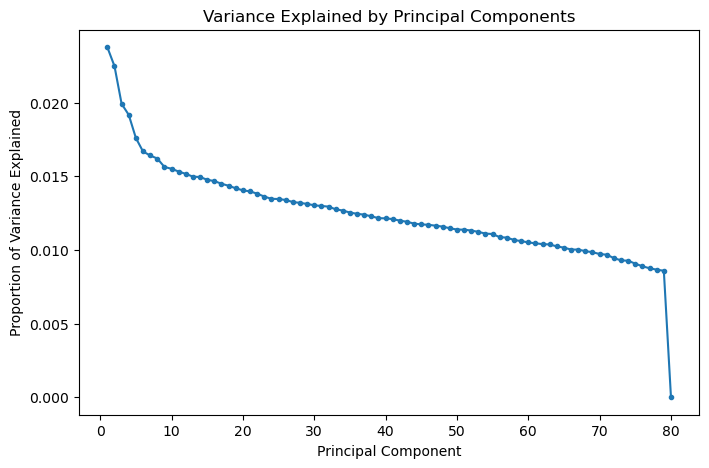

In [153]:
# Plot the variance explained by each principal component

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o',
    markersize=3
)

plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Variance Explained by Principal Components")

# Save figure to Figures folder
plt.savefig(
    "Figures/variance_explained_by_principal_components.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretation

The scree plot shows that the proportion of variance explained decreases gradually as the number of principal components increases. PC1 explains the largest proportion of variance (about 2.38%), followed by PC2 (about 2.25%). The first 10 principal components together explain approximately 18.34% of the total variance.

The variance is distributed across many principal components, which is reasonable because the dataset contains 4,431 word features. The final principal component explains essentially zero variance. With 80 training observations, the centered data matrix can have at most 79 principal components with nonzero variance.

## Principal Component Scores

The PCA transformation gives each article a score for every principal component. The first two principal component scores are examined to determine whether art and music articles show different patterns in the reduced-dimensional space.

In [154]:
# Display PC1 and PC2 scores for the first five articles
#:2 → first 2 principal components/columns
X_train_pca[:5, :2]

array([[ 0.26666034,  0.00468807],
       [-0.00180332, -0.05287393],
       [ 0.13570604, -0.06376461],
       [ 0.05711329, -0.03024325],
       [ 0.11066354,  0.12009584]])

## Visualization of Art and Music Articles Using PC1 and PC2

The first two principal component scores are plotted to examine whether art and music articles form distinct groups in the reduced-dimensional space.

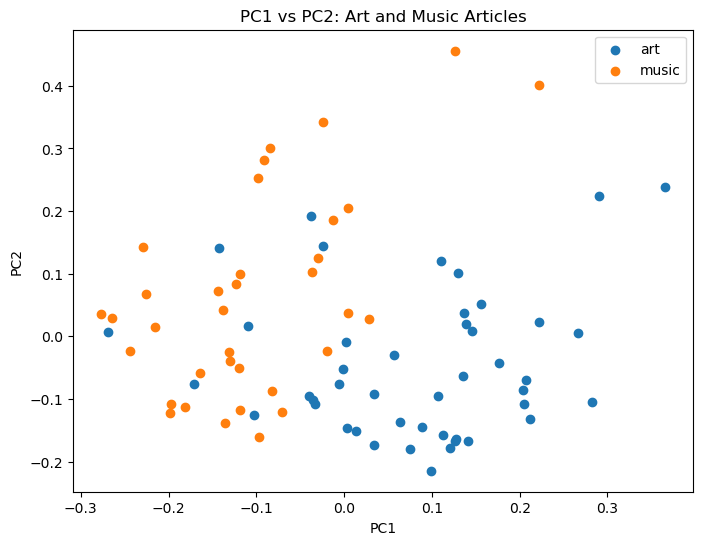

In [155]:
# Plot PC1 vs PC2 for art and music articles

plt.figure(figsize=(8, 6))

for label in ["art", "music"]:
    mask = y_train == label
    
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2: Art and Music Articles")
plt.legend()
# Save figure
plt.savefig(
    "Figures/pc1_vs_pc2_art_music.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretation

The PC1 vs PC2 plot shows the distribution of art and music articles in the first two principal component dimensions. The two classes show some separation, but there is also overlap between art and music articles. Therefore, the first two principal components capture some information related to article type, but they may not be sufficient for perfect classification.

## Logistic Regression Using the First Two Principal Components

A logistic regression model is fitted using PC1 and PC2 as predictors to classify the training articles as art or music.

In [156]:
# Select the first two principal components
#X_train_pca[:, :2]= first : → all 80 articles
#:2 → columns 0 and 1, which are PC1 and PC2

X_train_2pc = X_train_pca[:, :2]

X_train_2pc.shape

(80, 2)

In [157]:
# Fit logistic regression using PC1 and PC2

log_model = LogisticRegression()

log_model.fit(X_train_2pc, y_train)

LogisticRegression()

In [158]:
# Predict the classes of the training articles

y_train_pred = log_model.predict(X_train_2pc)

y_train_pred[:10]

array(['art', 'art', 'art', 'art', 'art', 'art', 'art', 'art', 'art',
       'art'], dtype=object)

In [159]:
# Calculate training accuracy and error rate

train_accuracy = accuracy_score(y_train, y_train_pred)
train_error = 1 - train_accuracy

print("Training Accuracy:", train_accuracy)
print("Training Error Rate:", train_error)

Training Accuracy: 0.775
Training Error Rate: 0.22499999999999998


### Training Performance

The logistic regression model using PC1 and PC2 achieved a training accuracy of **77.5%**, corresponding to a training error rate of **22.5%**. This indicates that the first two principal components contain useful information for distinguishing between art and music articles, although some articles are misclassified.

In [160]:
# Create confusion matrix for training predictions

cm_train = confusion_matrix(
    y_train,
    y_train_pred,
    labels=["art", "music"]
)

cm_train

array([[39,  6],
       [12, 23]], dtype=int64)

In [161]:
# Calculate class-specific training error rates

art_error = cm_train[0, 1] / cm_train[0].sum()
music_error = cm_train[1, 0] / cm_train[1].sum()

print("Art Error Rate:", art_error)
print("Music Error Rate:", music_error)

Art Error Rate: 0.13333333333333333
Music Error Rate: 0.34285714285714286


### Interpretation of Class-Specific Error Rates

The logistic regression model performs better for art articles than for music articles. The training error rate is approximately **13.33% for art** and **34.29% for music**. This indicates that music articles are more frequently misclassified as art when only PC1 and PC2 are used as predictors.

## Logistic Regression Decision Boundary

The decision boundary of the logistic regression model is visualized in the PC1-PC2 space to show how the model separates art and music articles.

In [162]:
# Create values covering the range of PC1 and PC2

x_min, x_max = X_train_2pc[:, 0].min(), X_train_2pc[:, 0].max()
y_min, y_max = X_train_2pc[:, 1].min(), X_train_2pc[:, 1].max()

print("PC1 range:", x_min, x_max)
print("PC2 range:", y_min, y_max)

PC1 range: -0.276828409288226 0.36538084454207653
PC2 range: -0.21453013139303503 0.45611919420389235


In [163]:
# Create a grid across the PC1 and PC2 space

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

print(xx.shape)
print(yy.shape)

(200, 200)
(200, 200)


In [164]:
# Convert the grid into PC1-PC2 coordinate pairs

grid_points = np.c_[xx.ravel(), yy.ravel()]

grid_points.shape

(40000, 2)

In [165]:
# Predict the class for each grid point

grid_pred = log_model.predict(grid_points)

grid_pred[:10]

array(['music', 'music', 'music', 'music', 'music', 'music', 'music',
       'music', 'music', 'music'], dtype=object)

In [166]:
# Reshape predictions back to the grid shape

Z = grid_pred.reshape(xx.shape)

Z.shape

(200, 200)

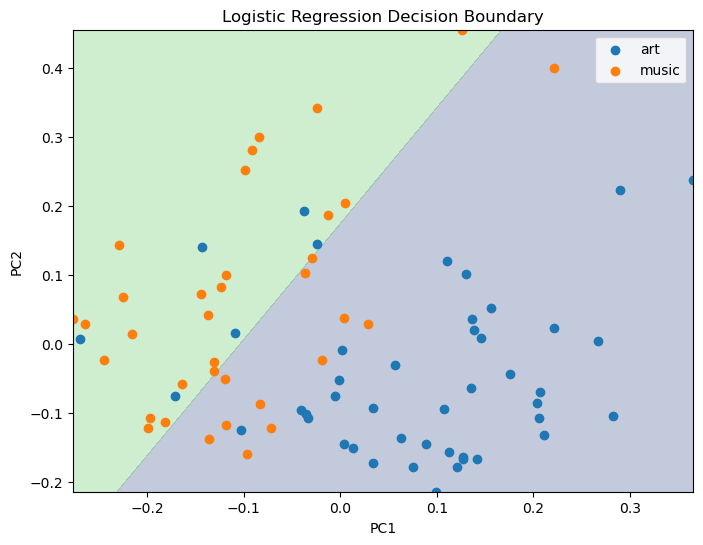

In [167]:
# Plot logistic regression decision boundary

plt.figure(figsize=(8, 6))

# Predict probability of the music class for each grid point
grid_prob = log_model.predict_proba(grid_points)[:, 1]

# Reshape probabilities back to the 200 x 200 grid
Z = grid_prob.reshape(xx.shape)

# Plot the decision regions
plt.contourf(
    xx, yy, Z,
    levels=[0, 0.5, 1],
    alpha=0.3
)

# Plot the actual training articles
for label in ["art", "music"]:
    mask = y_train == label

    plt.scatter(
        X_train_2pc[mask, 0],
        X_train_2pc[mask, 1],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()

# Save figure to Figures folder
plt.savefig(
    "Figures/logistic_regression_decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation of the Decision Boundary

The logistic regression decision boundary shows how the model separates art and music articles using PC1 and PC2. Most art articles fall on one side of the boundary, while many music articles fall on the other side. However, there is noticeable overlap between the two classes, resulting in some misclassification.

The model achieved a training accuracy of **77.5%** and a training error rate of **22.5%**. The class-specific error rates were **13.33% for art** and **34.29% for music**, indicating that the model has greater difficulty correctly classifying music articles using only the first two principal components.

## Test Set Evaluation

The test data are projected onto the principal components learned from the training data. The PCA model is not refitted on the test set, preventing information from the test data from influencing the fitted PCA transformation.

In [168]:
# Transform test data using the PCA fitted on training data

X_test_pca = pca.transform(X_test)

X_test_pca.shape

(22, 80)

In [169]:
# Select PC1 and PC2 from the test data

X_test_2pc = X_test_pca[:, :2]

X_test_2pc.shape

(22, 2)

In [170]:
# Predict classes for the test articles

y_test_pred = log_model.predict(X_test_2pc)

y_test_pred

array(['art', 'art', 'art', 'art', 'art', 'art', 'art', 'art', 'art',
       'art', 'art', 'art', 'music', 'music', 'art', 'art', 'art', 'art',
       'art', 'art', 'art', 'art'], dtype=object)

In [171]:
# Calculate test accuracy and error rate

test_accuracy = accuracy_score(y_test, y_test_pred)
test_error = 1 - test_accuracy

print("Test Accuracy:", test_accuracy)
print("Test Error Rate:", test_error)

Test Accuracy: 0.6363636363636364
Test Error Rate: 0.36363636363636365


In [172]:
# Create confusion matrix for test predictions

cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["art", "music"]
)

cm_test

array([[12,  0],
       [ 8,  2]], dtype=int64)

In [173]:
# Calculate class-specific test error rates

art_test_error = cm_test[0, 1] / cm_test[0].sum()
music_test_error = cm_test[1, 0] / cm_test[1].sum()

print("Art Test Error Rate:", art_test_error)
print("Music Test Error Rate:", music_test_error)

Art Test Error Rate: 0.0
Music Test Error Rate: 0.8


### Test Set Interpretation

The model achieved a test accuracy of **63.64%** and a test error rate of **36.36%**, which is higher than the training error rate of **22.5%**.

The class-specific results show a substantial difference in performance. All 12 art articles were classified correctly, giving an art error rate of **0%**. In contrast, 8 of the 10 music articles were misclassified as art, resulting in a music error rate of **80%**.

Therefore, using only PC1 and PC2 does not provide reliable classification of music articles on the test set. The higher test error compared with the training error also indicates that the two-PC model does not generalize particularly well to unseen articles.

## Selecting the Number of Principal Components

Instead of arbitrarily choosing the first two principal components, cross-validation can be used on the training data to select the number of PCs that provides the best classification performance.

In [174]:
# Import Pipeline

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [175]:
# Evaluate different numbers of principal components using 5-fold CV
# PCA is fitted separately within each cross-validation fold

cv_errors = []

for M in range(1, 64):

    model = Pipeline([
        ("pca", PCA(n_components=M)),
        ("logistic", LogisticRegression(max_iter=1000))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_error = 1 - scores.mean()
    cv_errors.append(cv_error)

In [176]:
# Find the number of PCs with the lowest cross-validation error

best_M = np.argmin(cv_errors) + 1
best_cv_error = np.min(cv_errors)

print("Best number of PCs:", best_M)
print("Lowest CV Error:", best_cv_error)

Best number of PCs: 45
Lowest CV Error: 0.375


## Cross-Validation Error vs. Number of Principal Components

The number of principal components is selected by comparing the 5-fold cross-validation error across models using different numbers of PCs.

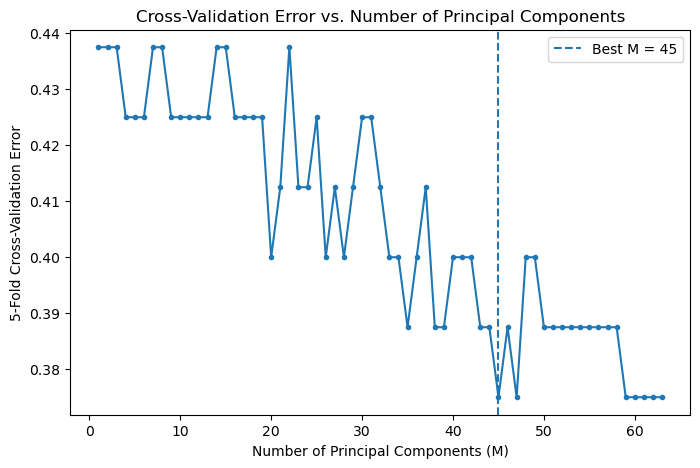

In [177]:
# Plot cross-validation error for different numbers of PCs

plt.figure(figsize=(8, 5))

plt.plot(
   range(1, len(cv_errors) + 1),
    cv_errors,
    marker="o",
    markersize=3
)

# Mark the best number of PCs
plt.axvline(
    x=best_M,
    linestyle="--",
    label=f"Best M = {best_M}"
)

plt.xlabel("Number of Principal Components (M)")
plt.ylabel("5-Fold Cross-Validation Error")
plt.title("Cross-Validation Error vs. Number of Principal Components")
plt.legend()

# Save figure
plt.savefig(
    "Figures/cv_error_vs_number_of_pcs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Using a PCA–logistic regression pipeline with 5-fold cross-validation, the lowest cross-validation error was approximately **37.5%**, obtained using **46 principal components**.

The cross-validation error generally decreases as more principal components are included, although there is considerable fluctuation across values of \(M\). This suggests that information useful for distinguishing art and music articles is distributed across multiple principal components rather than being concentrated only in PC1 and PC2.

Because the training dataset contains only 80 articles, the estimated cross-validation error may be unstable. Therefore, the exact choice of 46 PCs should be interpreted cautiously.

## Final Model Using the Cross-Validated Number of PCs

Based on 5-fold cross-validation, 46 principal components were selected. A final PCA–logistic regression model is fitted using all training observations and 46 principal components, then evaluated on the independent test set.

### Comparison with Principal Components Regression (PCR)

The approach used here is similar to Principal Components Regression (PCR), since both methods first apply PCA to the predictor variables and then use a selected number of principal components in a predictive model.

In classical PCR, the response variable is continuous and the selected principal components are used in a linear regression model. In this analysis, the response variable is categorical (art or music), so logistic regression is used instead.

In both approaches, the number of principal components, M, can be selected using cross-validation. An important limitation is that PCA constructs the principal components using only the predictor variables and does not consider the response when determining the principal component directions.

In [178]:
# Create the final PCA-logistic regression model using the selected M

final_model = Pipeline([
    ("pca", PCA(n_components=best_M)),
    ("logistic", LogisticRegression(max_iter=1000))
])

In [179]:
# Fit the final model using all training data

final_model.fit(X_train, y_train)

Pipeline(steps=[('pca', PCA(n_components=45)),
                ('logistic', LogisticRegression(max_iter=1000))])

In [180]:
# Predict the test articles using the final model

y_test_pred_final = final_model.predict(X_test)

y_test_pred_final

array(['art', 'art', 'art', 'art', 'art', 'art', 'art', 'art', 'art',
       'art', 'art', 'art', 'music', 'art', 'art', 'art', 'music',
       'music', 'art', 'art', 'art', 'art'], dtype=object)

In [181]:
# Calculate final test accuracy and error rate

final_test_accuracy = accuracy_score(y_test, y_test_pred_final)
final_test_error = 1 - final_test_accuracy

print("Final Test Accuracy:", final_test_accuracy)
print("Final Test Error Rate:", final_test_error)

Final Test Accuracy: 0.6818181818181818
Final Test Error Rate: 0.31818181818181823


In [182]:
# Confusion matrix for the final 46-PC model

cm_final = confusion_matrix(
    y_test,
    y_test_pred_final,
    labels=["art", "music"]
)

cm_final

array([[12,  0],
       [ 7,  3]], dtype=int64)

In [183]:
# Calculate class-specific test error rates

art_error_final = cm_final[0, 1] / cm_final[0].sum()
music_error_final = cm_final[1, 0] / cm_final[1].sum()

print("Art Test Error Rate:", art_error_final)
print("Music Test Error Rate:", music_error_final)

Art Test Error Rate: 0.0
Music Test Error Rate: 0.7


### Final Model Interpretation

The final PCA–logistic regression model used **46 principal components**, selected using 5-fold cross-validation. On the independent test set, the model achieved an accuracy of **68.18%** and an error rate of **31.82%**.

All 12 art articles were classified correctly, resulting in an **art error rate of 0%**. However, 7 of the 10 music articles were misclassified as art, resulting in a **music error rate of 70%**.

Compared with the original 2-PC logistic regression model, the cross-validated model improved the test accuracy from **63.64% to 68.18%** and reduced the music error rate from **80% to 70%**. Therefore, additional principal components provided some useful classification information, although the model still had difficulty identifying music articles.

## Conclusion

PCA was used to reduce the high-dimensional text data containing 4,431 word features into a smaller set of principal components. The first two PCs provided some separation between art and music articles, but substantial overlap remained.

A logistic regression model using only PC1 and PC2 achieved **63.64% test accuracy**. The number of principal components was then selected using a leakage-safe PCA–logistic regression pipeline with 5-fold cross-validation. The lowest cross-validation error occurred at **46 PCs**.

The final 46-PC model achieved **68.18% test accuracy**, providing a modest improvement over the 2-PC model. However, classification performance remained much stronger for art articles than for music articles.

Overall, the analysis demonstrates how PCA can be combined with logistic regression for dimensionality reduction and classification of high-dimensional text data, while also highlighting the importance of fitting preprocessing steps within cross-validation to avoid data leakage.